## load

In [35]:
import json

with open("annotated_data/conversations.json", "r", encoding="utf-8") as f:
    conversations = json.load(f)

with open("data/demographics.json", "r", encoding="utf-8") as f:
    demographics = json.load(f)

with open("annotated_data/nfr_responses.json", "r", encoding="utf-8") as f:
    nfr_responses = json.load(f)

with open("data/satisfaction_survey.json", "r", encoding="utf-8") as f:
    surveys = json.load(f)

GT = {}
with open("../GT/NFR_balancedt4.json", "r", encoding="utf-8") as f:
    for responses in json.load(f):
        for r in responses:
            GT[r['id']] = r





review attention questions

In [36]:
print("UUIDs with wrong attention questions!")
nfr_responses_filtered = {}
for pid, responses in nfr_responses.items():
    attention = responses[-1]
    if attention["nfr_display_1"] == "Agree" and attention["nfr_display_2"] == "Agree" and attention["nfr_feedback_1"] == "Disagree" and attention["nfr_feedback_2"] == "4":
        pass
    else:
        print("***********")
        print(pid)
        print(attention)

UUIDs with wrong attention questions!
***********
48b181c2-0689-4a5b-9d61-0644f4e37492
{'batch': 1, 'is_attention_question': True, 'nfr_display_1': 'Agree', 'nfr_display_2': 'Agree', 'nfr_feedback_1': 'Strongly Agree', 'nfr_feedback_2': '4', 'timestamp': '2026-03-09T15:09:27.444Z', 'uuid': '48b181c2-0689-4a5b-9d61-0644f4e37492', 'satisfaction_level': '', 'reasoning': '', 'code_location': [], 'comp': 0}
***********
2d83f401-5153-45ed-9078-1c31e035849a
{'batch': 5, 'is_attention_question': True, 'nfr_display_1': 'Disagree', 'nfr_display_2': 'Disagree', 'nfr_feedback_1': 'Disagree', 'nfr_feedback_2': '4', 'timestamp': '2026-03-17T18:23:42.252Z', 'uuid': '2d83f401-5153-45ed-9078-1c31e035849a', 'satisfaction_level': '', 'reasoning': '', 'code_location': [], 'comp': 0}
***********
614ad72b-57aa-4125-ab44-8e1e8a57910d
{'batch': 7, 'is_attention_question': True, 'nfr_display_1': 'Disagree', 'nfr_display_2': 'Disagree', 'nfr_feedback_1': 'Strongly Agree', 'nfr_feedback_2': '1', 'timestamp': '20

In [37]:
#removed_UUIDs = ["48b181c2-0689-4a5b-9d61-0644f4e37492", "2d83f401-5153-45ed-9078-1c31e035849a", '18d5b4e7-f5c2-4dd3-81d8-6f21ecc1962b', "614ad72b-57aa-4125-ab44-8e1e8a57910d"]
#nfr_responses_filtered = {i:j[:-1] for i,j in nfr_responses.items() if i not in removed_UUIDs}
UUIDS = ["78288bfa-e19e-4af8-acad-effa1e3aae35", "700f34fb-b376-44ef-98c3-a55a045abdd5", "b50b6c66-2252-47cf-a890-9f13757be68c", "e6991c2e-926c-4445-aae9-10a75496945f"]
nfr_responses_filtered = {i:j[:-1] for i,j in nfr_responses.items() if i in UUIDS}

In [38]:
nfr_responses_filtered.keys()

dict_keys(['e6991c2e-926c-4445-aae9-10a75496945f', 'b50b6c66-2252-47cf-a890-9f13757be68c', '700f34fb-b376-44ef-98c3-a55a045abdd5', '78288bfa-e19e-4af8-acad-effa1e3aae35'])

## Analysis 1. (agreement)
We calculate the participants’ level of agreement by calculating the mean of their agreement

In [39]:
n = 0
satisfaction_level_agreement = 0
reasoning_agreement = 0
code_location_agreement = 0
agreement_value = {"Strongly Agree":4, "Agree": 3, "Disagree": 2, "Strongly Disagree": 1}
for pid, responses in nfr_responses_filtered.items():
    for r in responses:
        n += 1
        satisfaction_level_agreement += agreement_value[r["q1_agreement"]]
        reasoning_agreement += agreement_value[r["q2_agreement"]]
        code_location_agreement += agreement_value[r["q3_agreement"]]

print("mean satisfaction level:", satisfaction_level_agreement / n)
print("mean reasoning agreement:", reasoning_agreement / n)
print("mean code location agreement:", code_location_agreement / n)

mean satisfaction level: 3.325
mean reasoning agreement: 3.275
mean code location agreement: 3.275


# analysis 1 more

In [40]:
import numpy as np

# Per-NFR breakdown to spot outliers
nfr_scores = {}
for pid, responses in nfr_responses_filtered.items():
    for r in responses:
        nfr_id = r["nfr_id"]  # adjust to your actual key
        if nfr_id not in nfr_scores:
            nfr_scores[nfr_id] = {"q1": [], "q2": [], "q3": []}
        nfr_scores[nfr_id]["q1"].append(agreement_value[r["q1_agreement"]])
        nfr_scores[nfr_id]["q2"].append(agreement_value[r["q2_agreement"]])
        nfr_scores[nfr_id]["q3"].append(agreement_value[r["q3_agreement"]])

for nfr_id, scores in nfr_scores.items():
    print(f"NFR {nfr_id}: "
          f"satisfaction={np.mean(scores['q1']):.2f}, "
          f"reasoning={np.mean(scores['q2']):.2f}, "
          f"code_loc={np.mean(scores['q3']):.2f}")

NFR 1: satisfaction=3.50, reasoning=3.50, code_loc=2.50
NFR 2: satisfaction=3.00, reasoning=3.50, code_loc=4.00
NFR 3: satisfaction=2.00, reasoning=2.00, code_loc=2.00
NFR 4: satisfaction=3.00, reasoning=3.00, code_loc=4.00
NFR 5: satisfaction=4.00, reasoning=4.00, code_loc=3.50
NFR 6: satisfaction=3.00, reasoning=3.50, code_loc=3.50
NFR 7: satisfaction=3.50, reasoning=3.50, code_loc=2.50
NFR 8: satisfaction=2.50, reasoning=2.50, code_loc=3.50
NFR 9: satisfaction=4.00, reasoning=3.50, code_loc=3.50
NFR 10: satisfaction=3.50, reasoning=3.50, code_loc=3.50
NFR 21: satisfaction=4.00, reasoning=3.00, code_loc=3.00
NFR 22: satisfaction=4.00, reasoning=4.00, code_loc=4.00
NFR 23: satisfaction=3.00, reasoning=4.00, code_loc=4.00
NFR 24: satisfaction=4.00, reasoning=3.00, code_loc=3.00
NFR 25: satisfaction=3.00, reasoning=4.00, code_loc=4.00
NFR 26: satisfaction=4.00, reasoning=3.00, code_loc=3.00
NFR 27: satisfaction=3.00, reasoning=4.00, code_loc=3.00
NFR 28: satisfaction=4.00, reasoning=3.0

Grouped Bar Chart

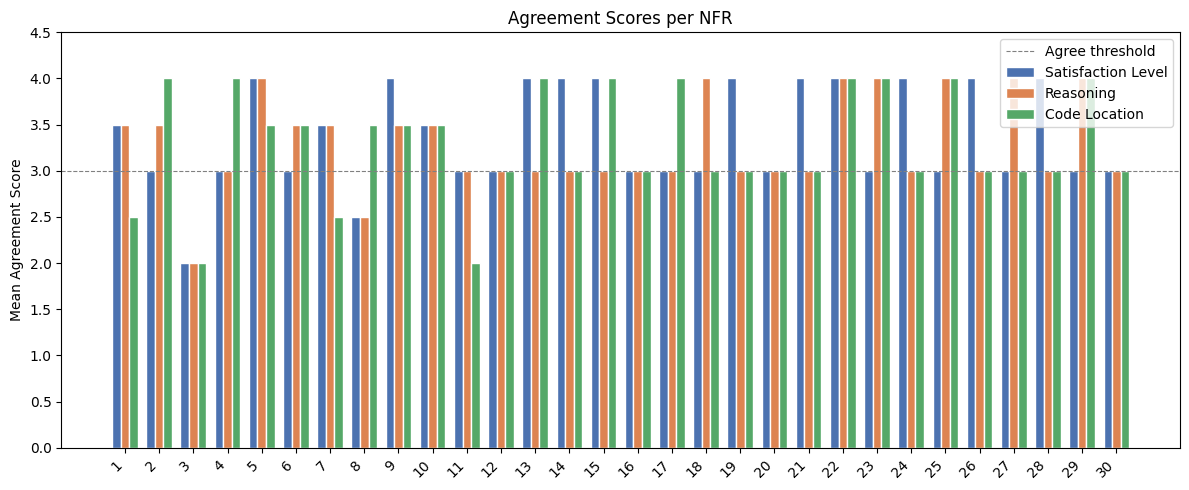

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Build a DataFrame from nfr_scores
df = pd.DataFrame({
    "NFR": list(nfr_scores.keys()),
    "Satisfaction Level": [np.mean(nfr_scores[nfr]["q1"]) for nfr in nfr_scores],
    "Reasoning":          [np.mean(nfr_scores[nfr]["q2"]) for nfr in nfr_scores],
    "Code Location":      [np.mean(nfr_scores[nfr]["q3"]) for nfr in nfr_scores],
}).set_index("NFR").sort_index()

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(df))
width = 0.25
bars = ["Satisfaction Level", "Reasoning", "Code Location"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

for i, (col, color) in enumerate(zip(bars, colors)):
    ax.bar(x + i * width, df[col], width, label=col, color=color, edgecolor="white")

ax.set_xticks(x + width)
ax.set_xticklabels(df.index, rotation=45, ha="right")
ax.set_ylabel("Mean Agreement Score")
ax.set_title("Agreement Scores per NFR")
ax.set_ylim(0, 4.5)
ax.axhline(y=3, color="gray", linestyle="--", linewidth=0.8, label="Agree threshold")
ax.legend()
plt.tight_layout()
plt.show()

Per-participant scores

                                      Satisfaction Level  Reasoning  \
e6991c2e-926c-4445-aae9-10a75496945f                 3.5        3.2   
b50b6c66-2252-47cf-a890-9f13757be68c                 2.9        3.3   
700f34fb-b376-44ef-98c3-a55a045abdd5                 3.5        3.5   
78288bfa-e19e-4af8-acad-effa1e3aae35                 3.4        3.1   

                                      Code Location  
e6991c2e-926c-4445-aae9-10a75496945f            3.2  
b50b6c66-2252-47cf-a890-9f13757be68c            3.3  
700f34fb-b376-44ef-98c3-a55a045abdd5            3.4  
78288bfa-e19e-4af8-acad-effa1e3aae35            3.2  


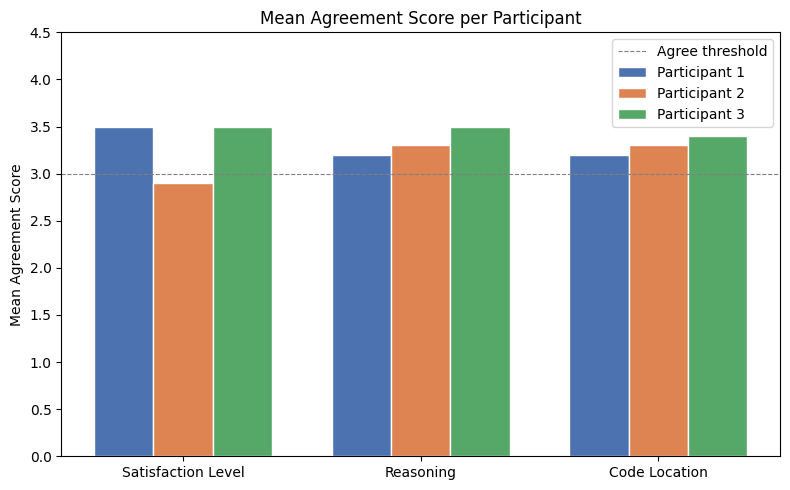

In [42]:
# ── Per-participant scores ────────────────────────────────────────────────────
participant_scores = {}
for pid, responses in nfr_responses_filtered.items():
    q1_scores, q2_scores, q3_scores = [], [], []
    for r in responses:
        q1_scores.append(agreement_value[r["q1_agreement"]])
        q2_scores.append(agreement_value[r["q2_agreement"]])
        q3_scores.append(agreement_value[r["q3_agreement"]])
    participant_scores[pid] = {
        "Satisfaction Level": q1_scores,
        "Reasoning":          q2_scores,
        "Code Location":      q3_scores,
    }

df_p = pd.DataFrame({
    pid: {col: np.mean(scores) for col, scores in qs.items()}
    for pid, qs in participant_scores.items()
}).T  # rows = participants, cols = questions

print(df_p.round(2))

# ── 1. Grouped Bar Chart (participants side by side) ──────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(df_p.columns))
width = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]

for i, (pid, color) in enumerate(zip(df_p.index, colors)):
    ax.bar(x + i * width, df_p.loc[pid], width, label=f"Participant {i+1}",
           color=color, edgecolor="white")

ax.set_xticks(x + width)
ax.set_xticklabels(df_p.columns)
ax.set_ylabel("Mean Agreement Score")
ax.set_title("Mean Agreement Score per Participant")
ax.set_ylim(0, 4.5)
ax.axhline(y=3, color="gray", linestyle="--", linewidth=0.8, label="Agree threshold")
ax.legend()
plt.tight_layout()
plt.show()


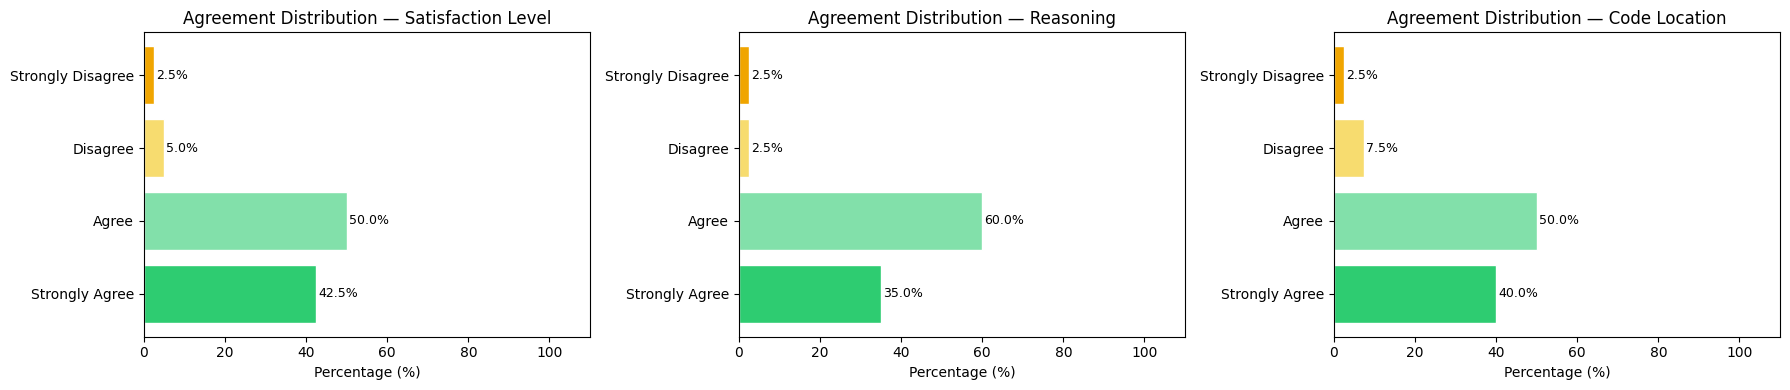

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

questions = [
    ("q1_agreement", "Satisfaction Level"),
    ("q2_agreement", "Reasoning"),
    ("q3_agreement", "Code Location")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
colors = ["#2ecc71", "#82e0aa", "#f7dc6f", "#f0a500", "#e74c3c"]
categories = ["Strongly Agree", "Agree", "Disagree", "Strongly Disagree"]

for ax, (q_key, q_label) in zip(axes, questions):
    all_responses = [r[q_key] for responses in nfr_responses_filtered.values() for r in responses]
    counts = Counter(all_responses)
    values = [counts.get(c, 0) for c in categories]
    total = sum(values)
    percentages = [v / total * 100 for v in values]

    bars = ax.barh(categories, percentages, color=colors, edgecolor="white")
    ax.set_xlabel("Percentage (%)")
    ax.set_title(f"Agreement Distribution — {q_label}")
    for bar, pct in zip(bars, percentages):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{pct:.1f}%", va="center", fontsize=9)
    ax.set_xlim(0, 110)

plt.tight_layout()
plt.show()

Inter-rater reliability

In [44]:
from sklearn.metrics import cohen_kappa_score
import krippendorff
import numpy as np

# Build a matrix: rows = participants, cols = NFRs
# For each question separately
def build_rating_matrix(nfr_responses_filtered, agreement_value, question_key):
    all_pids = list(nfr_responses_filtered.keys())
    all_nfrs = sorted({r["nfr_id"] for responses in nfr_responses_filtered.values() for r in responses})
    
    matrix = []
    for pid in all_pids:
        row = []
        pid_nfr_map = {r["nfr_id"]: r for r in nfr_responses_filtered[pid]}
        for nfr_id in all_nfrs:
            if nfr_id in pid_nfr_map:
                row.append(agreement_value[pid_nfr_map[nfr_id][question_key]])
            else:
                row.append(np.nan)  # missing
        matrix.append(row)
    return np.array(matrix, dtype=float), all_nfrs

cutoff = 4 / 6
for q_key, q_label in [("q1_agreement", "Satisfaction"), ("q2_agreement", "Reasoning"), ("q3_agreement", "Code Location")]:
    matrix, nfr_ids = build_rating_matrix(nfr_responses_filtered, agreement_value, q_key)
    #print(matrix)
    print(q_label)
    for j, nfr in enumerate(nfr_ids):
        col = [matrix[i][j] for i in range(len(matrix)) if not np.isnan(matrix[i][j])]
        mu = np.mean(col)
        ad = np.mean(np.abs(np.array(col) - mu))
        if ad > cutoff:
            print(f"  NFR {nfr}: mean={mu:.2f}, AD={ad:.2f}") # , col={col}
        

Satisfaction
  NFR 3: mean=2.00, AD=1.00
  NFR 4: mean=3.00, AD=1.00
Reasoning
  NFR 3: mean=2.00, AD=1.00
Code Location
  NFR 3: mean=2.00, AD=1.00


In [45]:
from sklearn.metrics import cohen_kappa_score
import krippendorff
import numpy as np

# Build a matrix: rows = participants, cols = NFRs
# For each question separately
def build_rating_matrix(nfr_responses_filtered, agreement_value, question_key):
    all_pids = list(nfr_responses_filtered.keys())
    all_nfrs = sorted({r["nfr_id"] for responses in nfr_responses_filtered.values() for r in responses})
    
    matrix = []
    for pid in all_pids:
        row = []
        pid_nfr_map = {r["nfr_id"]: r for r in nfr_responses_filtered[pid]}
        for nfr_id in all_nfrs:
            if nfr_id in pid_nfr_map:
                row.append(agreement_value[pid_nfr_map[nfr_id][question_key]])
            else:
                row.append(np.nan)  # missing
        matrix.append(row)
    return np.array(matrix, dtype=float), all_nfrs

for q_key, q_label in [("q1_agreement", "Satisfaction"), ("q2_agreement", "Reasoning"), ("q3_agreement", "Code Location")]:
    matrix, nfr_ids = build_rating_matrix(nfr_responses_filtered, agreement_value, q_key)
    # Krippendorff's alpha handles missing data and ordinal scale
    print(matrix)
    alpha = krippendorff.alpha(reliability_data=matrix, level_of_measurement='ordinal')
    print(f"{q_label} — Krippendorff's α: {alpha:.3f}")
    

[[ 4.  3.  3.  4.  4.  3.  4.  3.  4.  3. nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan]
 [ 3.  3.  1.  2.  4.  3.  3.  2.  4.  4. nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan  4.  4.  3.  4.  3.  4.  3.  4.  3.  3.]
 [nan nan nan nan nan nan nan nan nan nan  3.  3.  4.  4.  4.  3.  3.  3.
   4.  3. nan nan nan nan nan nan nan nan nan nan]]
Satisfaction — Krippendorff's α: 0.169
[[ 4.  3.  3.  3.  4.  3.  3.  3.  3.  3. nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan]
 [ 3.  4.  1.  3.  4.  4.  4.  2.  4.  4. nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan  3.  4.  4.  3.  4.  3.  4.  3.  4.  3.]
 [nan nan nan nan nan nan nan nan nan nan  3.  3.  3.  3.  3.  3.  3.  4.
   3.  3. n

Satatistical analysis

In [46]:
import numpy as np
import pandas as pd
from scipy import stats

agreement_value = {"Strongly Agree":4, "Agree": 3, "Disagree": 2, "Strongly Disagree": 1}

# Build a tidy long-form DataFrame — this is the foundation for everything
records = []
for pid, responses in nfr_responses_filtered.items():
    for r in responses:
        records.append({
            "participant": pid,
            "nfr_id": r["nfr_id"],
            "satisfaction": agreement_value[r["q1_agreement"]],
            "reasoning":    agreement_value[r["q2_agreement"]],
            "code_location": agreement_value[r["q3_agreement"]],
        })

df = pd.DataFrame(records)

In [47]:
###
from scipy.stats import ttest_1samp

print("=== Test 1: Is agreement significantly above 3? ===")
print("H0: mean <= 3 | H1: mean > 3\n")

for dim, label in zip(["satisfaction", "reasoning", "code_location"],
                       ["Satisfaction Level", "Reasoning", "Code Location"]):
    scores = df[dim].values
    print(scores)
    stat, p = ttest_1samp(scores, popmean=3, alternative="greater")
    mean_val = np.mean(scores)
    std_val = np.std(scores, ddof=1)
    print(f"{label}:")
    print(f"  Mean = {mean_val:.3f}, SD = {std_val:.3f}")
    print(f"  t = {stat:.3f}, p = {p:.4f} ({'significant' if p < 0.05 else 'not significant'})\n")

=== Test 1: Is agreement significantly above 3? ===
H0: mean <= 3 | H1: mean > 3

[4 3 3 4 4 3 4 3 4 3 3 3 1 2 4 3 3 2 4 4 4 4 3 4 3 4 3 4 3 3 3 3 4 4 4 3 3
 3 4 3]
Satisfaction Level:
  Mean = 3.325, SD = 0.694
  t = 2.962, p = 0.0026 (significant)

[4 3 3 3 4 3 3 3 3 3 3 4 1 3 4 4 4 2 4 4 3 4 4 3 4 3 4 3 4 3 3 3 3 3 3 3 3
 4 3 3]
Reasoning:
  Mean = 3.275, SD = 0.640
  t = 2.718, p = 0.0049 (significant)

[3 4 3 4 3 3 2 4 3 3 2 4 1 4 4 4 3 3 4 4 3 4 4 3 4 3 3 3 4 3 2 3 4 3 4 3 4
 3 3 3]
Code Location:
  Mean = 3.275, SD = 0.716
  t = 2.430, p = 0.0099 (significant)



## Analysis 2. (accuracy of LLMs' evaluation of satisfaction level, reasoning, and code location)
We first extract the LLM's responses on satisfaction level, reasoning, and code location by manually reviewing the dialogues.
- For the satisfaction level, we calculate the F1 score between the extracted LLM response and the ground truth.
- For the reasoning, we measure accuracy as the mean of the similarity between the LLM’s response and the ground truth. We calculate this similarity using ROUGE or BERTScore.
- For code location, we compute the F1 score by defining true positives as |G ∩ P|, False Positives as |P \ G|, and False Negatives as |G \ P|, where G is the ground truth set, and P is the extracted Set.

### satisfaction level

In [48]:
y_true = []
y_pred = []
satisfavtion_levels = ["satisfied", "weakly satisfied", "weakly denied", "denied", "na"]
for pid, responses in nfr_responses_filtered.items():
    for response in responses:
        id = response['nfr_id']
        y1 = response["satisfaction_level"].lower()
        y2 = GT[id]["satisfaction_level"].lower()
        if y2 not in satisfavtion_levels:
            raise Exception(f'error {id} GT')
        if y1 not in satisfavtion_levels:
            raise Exception(f'error {id} {pid}')
        y_true.append(y2)
        y_pred.append(y1)


In [49]:
from sklearn.metrics import f1_score, precision_score, recall_score

precision = precision_score(y_true, y_pred, average="macro")
recall = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")

print(f"Macro Precision: {precision:.3f}")
print(f"Macro Recall:    {recall:.3f}")
print(f"Macro F1 Score:  {f1:.3f}")

Macro Precision: 0.361
Macro Recall:    0.259
Macro F1 Score:  0.260


/opt/miniconda3/envs/dialogue/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### reasoning

In [50]:
# pip install bert-score
# pip install transformers
# https://haticeozbolat17.medium.com/text-summarization-how-to-calculate-bertscore-771a51022964
#from transformers import BertTokenizer, BertForMaskedLM, BertModel
from transformers import BertTokenizer, BertForMaskedLM, BertModel
from bert_score import BERTScorer
import torch
import numpy as np

# Example texts
reference = "This is a reference text example."
candidate = "This is a candidate text example."
# BERTScore calculation
scorer = BERTScorer(model_type='bert-base-uncased')

def get_bert_score(reference, candidate):
    P, R, F1 = scorer.score([candidate], [reference])
    return P, R, F1

P, R, F1 = get_bert_score(reference, candidate)
print(f"BERTScore Precision: {P.mean():.4f}, Recall: {R.mean():.4f}, F1: {F1.mean():.4f}")

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased")

def get_bert_cosine_sim(text1, text2):
    inputs1 = tokenizer(text1, return_tensors="pt", padding=True, truncation=True)
    inputs2 = tokenizer(text2, return_tensors="pt", padding=True, truncation=True)
    outputs1 = model(**inputs1)
    outputs2 = model(**inputs2)
    embeddings1 = outputs1.last_hidden_state.mean(dim=1).detach().numpy()
    embeddings2 = outputs2.last_hidden_state.mean(dim=1).detach().numpy()
    similarity = np.dot(embeddings1, embeddings2.T) / (np.linalg.norm(embeddings1) * np.linalg.norm(embeddings2))
    return similarity

text1 = "This is an example text."
text2 = "This text contains an example sentence."
similarity = get_bert_cosine_sim(text1, text2)
print("Similarity between the texts: {:.4f}".format(similarity[0][0]))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1591.86it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERTScore Precision: 0.9258, Recall: 0.9258, F1: 0.9258


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1640.95it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Similarity between the texts: 0.9000


In [51]:
y_p = []
y_r = []
y_f = []
y_s = []
reasonings = []

for pid, responses in nfr_responses_filtered.items():
    for response in responses:
        id = response['nfr_id']
        y1 = response["reasoning"]
        y2 = GT[id]["reasoning"]
        P, R, F1 = get_bert_score(y1, y2)
        similarity = get_bert_cosine_sim(y1, y2)
        y_p.append(P.item())
        y_r.append(R.item())
        y_f.append(F1.item())
        y_s.append(similarity)
        reasonings.append((y1, y2))


print(f"BERTScore F1: {np.mean(y_f):.4f} ± {np.std(y_f):.4f}")
print(f"BERTScore P:  {np.mean(y_p):.4f} ± {np.std(y_p):.4f}")
print(f"BERTScore R:  {np.mean(y_r):.4f} ± {np.std(y_r):.4f}")
print(f"Cosine Sim:   {np.mean(y_s):.4f} ± {np.std(y_s):.4f}")

        

BERTScore F1: 0.5204 ± 0.0495
BERTScore P:  0.5368 ± 0.0730
BERTScore R:  0.5130 ± 0.0624
Cosine Sim:   0.7959 ± 0.0610


In [52]:
import numpy as np

max_idx = np.argmax(y_s)
min_idx = np.argmin(y_s)


print("Highest similarity:")
print(y_s[max_idx])
print("y1:", reasonings[max_idx][0])
print("y2:", reasonings[max_idx][1])
print("\nLowest similarity:")
print(y_s[min_idx])
print("y1:", reasonings[min_idx][0])
print("y2:", reasonings[min_idx][1])

Highest similarity:
[[0.9117736]]
y1: Evidence: All actions are logged to `transactionlog` via `TransactionDAO.logTransaction`. Users can review access activity in `viewAccessLog.jsp`, and full logs are viewable in `transactionLog.jsp`. Incident data is therefore captured. Gaps: No incident response workflow—no alerts, thresholds, or remediation steps; logging is passive only. No documented playbooks or automated containment/detection, so support for incident handling is minimal.
y2: The system does implement recording of some activities (transaction log, login success/failure), but it does not cover all activity involving PHI. Several actions that use PHI (PayBillAction, ViewClaimsAction, VerifyClaimAction, SearchUsersAction, ActivityFeedAction) do not log, and there is no logging of every database request that touches PHI.

Lowest similarity:
[[0.6682169]]
y1: `users` table uses `MID` as PK, and `PersonnelDAO.getNextID` generates unique IDs per role prefix.
y2: the system does assign

### code locations

In [53]:
y_p = []
y_r = []
y_f = []
y_s = []
reasonings = []


def intervals_overlap(list_a, list_b):
    def parse(intervals):
        intervals = [s if '-' in s else s + '-' + str(int(s)+1) for s in intervals]
        return [(int(s.split('-')[0]), int(s.split('-')[1])) for s in intervals]
    
    for a_start, a_end in parse(list_a):
        for b_start, b_end in parse(list_b):
            if a_start <= b_end and b_start <= a_end:
                return True
    return False    

for pid, responses in nfr_responses_filtered.items():
    for response in responses:
        id = response['nfr_id']
        y1 = response["code_location"]
        y2 = GT[id]["code_location"]
        temp = []
        for code_r in y1:
            gt_found = False
            for code_gt in y2:
                code_r_file = code_r[:code_r.find(' ')]
                code_r_line = code_r[1+ code_r.find(' '):].split(' ')
                code_gt_file = code_gt[:code_gt.find(' ')]
                code_gt_line = code_gt[1+ code_gt.find(' '):].split(' ')
                if code_r_file == code_gt_file:
                    if intervals_overlap(code_r_line, code_gt_line):
                        temp.append(code_gt)
                        gt_found = True
            if gt_found == False:
                temp.append(code_r)
            
        y1=temp

        if response['satisfaction_level'] == "Denied" or GT[id]['satisfaction_level'] == "Denied":
            continue
        
        y1 = set(y1)
        y2 = set(y2)

        # True Positive is intersection of y1 and y2
        TP = len(y1.intersection(y2))
        if TP == 0:
            p = 0
            r = 0
            f1 = 0
        else:
            p = TP/len(y1)
            r = TP/len(y2)
            f1 = 2 * ((p*r)/(p+r))

        y_p.append(p)
        y_r.append(r)
        y_f.append(f1)        
        reasonings.append((y1, y2))

print()
print(f"F1: {np.mean(y_f):.4f} ± {np.std(y_f):.4f}")
print(f"P:  {np.mean(y_p):.4f} ± {np.std(y_p):.4f}")
print(f"R:  {np.mean(y_r):.4f} ± {np.std(y_r):.4f}")


F1: 0.3486 ± 0.3133
P:  0.3140 ± 0.3072
R:  0.4491 ± 0.4037


In [54]:
import numpy as np

max_idx = np.argmax(y_f)
min_idx = np.argmin(y_f)


print("Highest similarity:")
print(y_f[max_idx])
print("y1:", reasonings[max_idx][0])
print("y2:", reasonings[max_idx][1])
print("\nLowest similarity:")
print(y_f[min_idx])
print("y1:", reasonings[min_idx][0])
print("y2:", reasonings[min_idx][1])

Highest similarity:
1.0
y1: {'ViewMyRecordsAction.java 87-89', 'viewMyRecords.jsp 78-100 47-51'}
y2: {'ViewMyRecordsAction.java 87-89', 'viewMyRecords.jsp 78-100 47-51'}

Lowest similarity:
0
y1: {'ResetPasswordAction.java 226-239'}
y2: {'AddPHAAction.java 51-53', 'AddHCPAction.java 52-54', 'AddLTAction.java 46-48', 'AddUAPAction.java 52-54', 'AddPatientAction.java 65-75 50-53', 'AddERespAction.java 54-56'}


# analysis 2 more

In [55]:
rows = []
all_nfrs = sorted({r["nfr_id"] for responses in nfr_responses_filtered.values() for r in responses})
pids = sorted(nfr_responses_filtered.keys())

for nfr_id in all_nfrs:
    row = {"NFR ID": nfr_id, "GT": GT[nfr_id]["satisfaction_level"]}
    for i, pid in enumerate(pids):
        pid_map = {r["nfr_id"]: r for r in nfr_responses_filtered[pid]}
        row[f"Participant {i+1}"] = pid_map.get(nfr_id, {}).get("satisfaction_level", "N/A")
    rows.append(row)

df_table = pd.DataFrame(rows).set_index("NFR ID")
print(df_table.to_string())

                      GT Participant 1     Participant 2     Participant 3     Participant 4
NFR ID                                                                                      
1              Satisfied           N/A               N/A  Weakly Satisfied  Weakly Satisfied
2              Satisfied           N/A               N/A  Weakly Satisfied  Weakly Satisfied
3              Satisfied           N/A               N/A  Weakly Satisfied  Weakly Satisfied
4              Satisfied           N/A               N/A  Weakly Satisfied  Weakly Satisfied
5          Weakly Denied           N/A               N/A  Weakly Satisfied            Denied
6          Weakly Denied           N/A               N/A     Weakly Denied            Denied
7          Weakly Denied           N/A               N/A            Denied            Denied
8                 Denied           N/A               N/A     Weakly Denied  Weakly Satisfied
9                 Denied           N/A               N/A            De

## Analysis 3.(significant dialogue costs)
To determine which dialogue metrics (Table 1) significantly correlate with dialogue performance, we first manually review the dialogues to extract dialogue cost values. For example, the mean elapsed time is calculated by dividing the difference between the first and last message submission times in the chatbot by the number of tasks assigned to the user. Or, task completion is 1 when satisfaction level, reasoning, and code location are identified in the dialogues; otherwise, it's 0. The number of user initiatives is the number of times a user doesn't ask a follow-up question to the previous message, and so on. For task success, we calculate Cohen's kappa between the LLM's response and the ground truth. We then measure user satisfaction by summing the Likert scores in the post-study survey questions (Table 2). Based on the Paradise framework, the performance of a dialogue system (i.e., the prediction of user satisfaction) is modeled as a multiple linear regression of dialogue costs (independent variables). We can determine whether there is any significant relationship between the performance and any of the dialogue costs. A common procedure for testing the significance of variables in a multiple linear regression model is to run an 'Omnibus' test followed by 'Post-Hoc' tests.


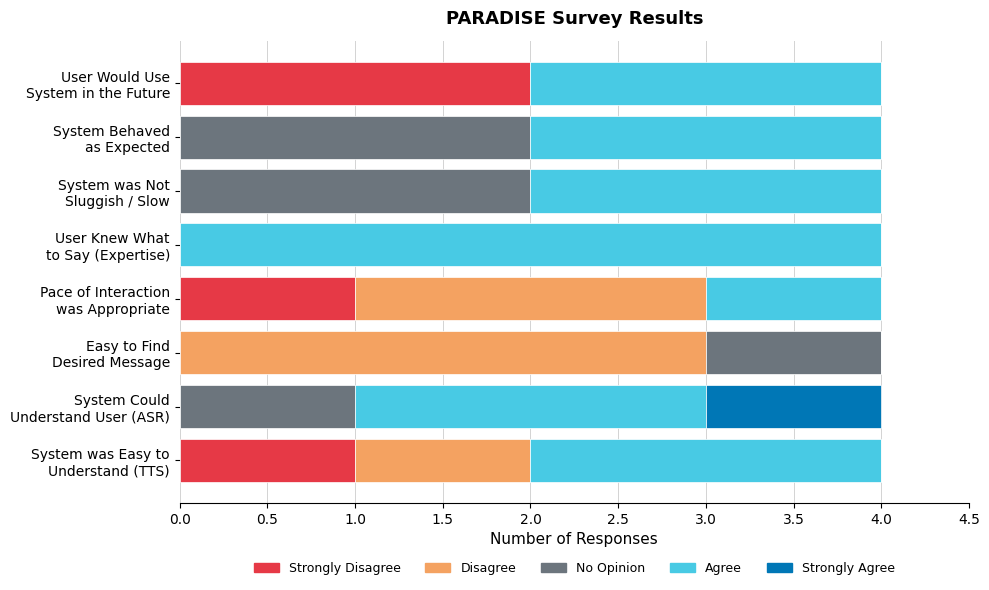

In [56]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter

questions = { #todo doouble check
    "q1": "System was Easy to\nUnderstand (TTS)",
    "q2": "System Could\nUnderstand User (ASR)",
    "q3": "Easy to Find\nDesired Message",
    "q4": "Pace of Interaction\nwas Appropriate",
    "q5": "User Knew What\nto Say (Expertise)",
    "q6": "System was Not\nSluggish / Slow",
    "q7": "System Behaved\nas Expected",
    "q8": "User Would Use\nSystem in the Future",
}

label_map = {
    "1": "Strongly Disagree",
    "2": "Disagree",
    "3": "No Opinion",
    "4": "Agree",
    "5": "Strongly Agree",
}

categories = ["Strongly Disagree", "Disagree", "No Opinion", "Agree", "Strongly Agree"]

colors = {
    "Strongly Disagree": "#E63946",
    "Disagree":          "#F4A261",
    "No Opinion":        "#6C757D",
    "Agree":             "#48CAE4",
    "Strongly Agree":    "#0077B6",
}


q_keys = list(questions.keys())          # q1 … q8
counts = {q: Counter() for q in q_keys}
surveys = {i:j for i, j in surveys.items() if i in nfr_responses_filtered}
for participant in surveys.values():
    for q in q_keys:
        raw = participant.get(q)
        if raw is not None:
            counts[q][label_map[str(raw)]] += 1

# Build a matrix: rows = questions, cols = categories
n_q = len(q_keys)
data = np.zeros((n_q, len(categories)), dtype=float)
for i, q in enumerate(q_keys):
    for j, cat in enumerate(categories):
        data[i, j] = counts[q].get(cat, 0)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(n_q)

for j, cat in enumerate(categories):
    lefts = data[:, :j].sum(axis=1)
    ax.barh(
        y_pos,
        data[:, j],
        left=lefts,
        color=colors[cat],
        edgecolor="white",
        linewidth=0.5,
        label=cat,
    )

# ── Axis formatting ───────────────────────────────────────────────────────────
ax.set_yticks(y_pos)
ax.set_yticklabels([questions[q] for q in q_keys], fontsize=10)
ax.set_xlabel("Number of Responses", fontsize=11)
ax.set_xlim(0, len(surveys) + 0.5)           # adjust if dataset grows

# Grid lines (vertical, light)
ax.set_axisbelow(True)
ax.xaxis.grid(True, color="lightgrey", linewidth=0.7)
ax.spines[["top", "right", "left"]].set_visible(False)

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [
    mpatches.Patch(color=colors[c], label=c) for c in categories
]
ax.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=5,
    frameon=False,
    fontsize=9,
)


plt.title("PARADISE Survey Results", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()


In [57]:
from datetime import datetime
def ttoi(i):
    return datetime.fromisoformat(i).timestamp()


In [58]:
for pid, dialogues in conversations.items():
    print('-------')
    print(pid)
    print(len(dialogues))
    y1 = ttoi(dialogues[-1]["bot_time"])
    y2 = ttoi(dialogues[0]["user_time"])
    print((y1-y2)/60)

-------
48b181c2-0689-4a5b-9d61-0644f4e37492
1
3.227548817793528
-------
e7c3d057-f0bb-4f30-aea0-ab689f9412ac
21
33.09105974833171
-------
18d5b4e7-f5c2-4dd3-81d8-6f21ecc1962b
27
648.1311413327853
-------
2d83f401-5153-45ed-9078-1c31e035849a
3
42.16669166485469
-------
e6991c2e-926c-4445-aae9-10a75496945f
25
56.881873897711436
-------
b50b6c66-2252-47cf-a890-9f13757be68c
22
41.53640078306198
-------
700f34fb-b376-44ef-98c3-a55a045abdd5
3
3.8840447505315145
-------
78288bfa-e19e-4af8-acad-effa1e3aae35
11
33.23308908144633


In [59]:
from sklearn.metrics import cohen_kappa_score
rows = []
for pid, dialogues in conversations.items():
    if pid not in nfr_responses_filtered:
        continue
    nfrs = nfr_responses_filtered[pid]
    num_tasks = len(nfr_responses_filtered)
    num_turn = len(dialogues)
    ids = [i["nfr_id"] for i in nfrs]
    # TODO k
    y1 = [i["satisfaction_level"] for i in nfrs]
    y2 = [GT[id]["satisfaction_level"] for id in ids]
    K = cohen_kappa_score(y1, y2)
    #MUM
    MUM = len(dialogues) / num_tasks
    #MET
    y1 = ttoi(dialogues[-1]["bot_time"])
    y2 = ttoi(dialogues[0]["user_time"])
    MET = (y1 - y2) / num_tasks
    # Comp
    Comp = sum([i["comp"] for i in nfrs])/ num_tasks
    # NUI
    NUI = sum(1 for i in dialogues if i["UI"])
    # MWT
    MWT = sum(len(d["user_message"]) for d in dialogues) / num_turn
    # MRT
    MRT = sum(ttoi(d["bot_time"]) - ttoi(d["user_time"]) for d in dialogues) / num_turn
    # NRT NA
    # NUR
    NUR = sum(1 for i in dialogues if i["UR"])
    # NIR & IRR
    NIR = sum(1 for i in dialogues if i["IR"])
    IRR = sum(1 for i in dialogues if i["IR"]) / num_turn
    # Error
    Error = sum(1 for i in dialogues if i["Error"])
    # NHM & IRR
    NHM = sum(1 for i in dialogues if i["HM"])
    HMR = sum(1 for i in dialogues if i["HM"]) / num_turn  
    # NCM & CMR TODO
    #NCM = sum(1 for i in dialogues if i["CM"])
    #CMR = sum(1 for i in dialogues if i["CM"]) / num_turn   
    # NGD & GDR
    NGD = sum(1 for i in dialogues if i["GD"])
    GDR = sum(1 for i in dialogues if i["GD"]) / num_turn 
    # NRD & RDR
    NRD = sum(1 for i in dialogues if i["RD"])
    RDR = sum(1 for i in dialogues if i["RD"]) / num_turn 
    # NAR & ARR
    NAR = sum(1 for i in dialogues if i["AR"])
    ARR = sum(1 for i in dialogues if i["AR"]) / num_turn  
    
    Recollections = sum(1 for i in dialogues if i.get("Recollections", ""))
    Expansion = sum(1 for i in dialogues if i.get("Expansion", ""))
    Refinement = sum(1 for i in dialogues if i.get("Refinement", ""))
    Follow_up = sum(1 for i in dialogues if i.get("Follow-up", ""))

    Context_Memory = sum(1 for i in dialogues if i.get("Context Memory", ""))
    Self_correction = sum(1 for i in dialogues if i.get("Self-correction", ""))
    Self_affirmation = sum(1 for i in dialogues if i.get("Self-affirmation", ""))
    Proactive_Interaction = sum(1 for i in dialogues if i.get("Proactive Interaction", ""))
    Instruction_Clarification = sum(1 for i in dialogues if i.get("Instruction Clarification", ""))

    Content_Confusion = sum(1 for i in dialogues if i.get("Content Confusion", ""))
    Content_Rephrasing = sum(1 for i in dialogues if i.get("Content Rephrasing", ""))
    Format_Rephrasing = sum(1 for i in dialogues if i.get("Format Rephrasing", ""))

    US = surveys[pid]
    US_total = int(US["q1"]) + int(US["q2"]) + int(US["q3"]) + int(US["q4"]) + int(US["q5"]) + int(US["q6"]) + int(US["q7"]) + int(US["q8"]) 
    print(US_total)
    rows.append({
        "pid": pid, "K": K, "MUM": MUM, "MET": MET, "Comp": Comp,
        "NUI": NUI, "MWT": MWT, "MRT": MRT, "NUR": NUR,
        "NIR": NIR, "IRR": IRR, "Error": Error,
        "NHM": NHM, "HMR": HMR, "NGD": NGD, "GDR": GDR,
        "NRD": NRD, "RDR": RDR, "NAR": NAR, "ARR": ARR,
        "Recollections": Recollections, "Expansion": Expansion, "Refinement": Refinement, "Follow-up": Follow_up,
        "Context_Memory": Context_Memory, "Self_correction": Self_correction,
        "Self_affirmation": Self_affirmation, "Proactive_Interaction": Proactive_Interaction,
        "Instruction_Clarification": Instruction_Clarification,
        "Content Confusion": Content_Confusion, "Content Rephrasing": Content_Rephrasing, "Format Rephrasing": Format_Rephrasing,
        "US": US_total
    })






24
20
25
30


In [60]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

df = pd.DataFrame(rows)
predictors = [c for c in df.columns if c not in ['pid', 'US']]
# 2. Multiple regression
X = df[predictors]
X = sm.add_constant(X)
y = df['US']
model = sm.OLS(y, X).fit()
print("\n=== OLS Regression Summary ===")
print(model.summary())



=== OLS Regression Summary ===
                            OLS Regression Results                            
Dep. Variable:                     US   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Wed, 25 Mar 2026   Prob (F-statistic):                nan
Time:                        16:52:31   Log-Likelihood:                 121.23
No. Observations:                   4   AIC:                            -234.5
Df Residuals:                       0   BIC:                            -236.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

/opt/miniconda3/envs/dialogue/lib/python3.10/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/opt/miniconda3/envs/dialogue/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/opt/miniconda3/envs/dialogue/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/opt/miniconda3/envs/dialogue/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
/opt/miniconda3/envs/dialogue/lib/python3.10/site-packages/statsmodels/

In [61]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

df = pd.DataFrame(rows)
predictors = ["Self_correction"]
# 2. Multiple regression
X = df[predictors]
X = sm.add_constant(X)
y = df['US']
model = sm.OLS(y, X).fit()
print("\n=== OLS Regression Summary ===")
print(model.summary())



=== OLS Regression Summary ===
                            OLS Regression Results                            
Dep. Variable:                     US   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                 -0.259
Method:                 Least Squares   F-statistic:                    0.3836
Date:                Wed, 25 Mar 2026   Prob (F-statistic):              0.599
Time:                        16:52:31   Log-Likelihood:                -10.406
No. Observations:                   4   AIC:                             24.81
Df Residuals:                       2   BIC:                             23.58
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const     

/opt/miniconda3/envs/dialogue/lib/python3.10/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [62]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
for i in df.columns:
    if i == "pid":
        continue
    print('*'*10)
    print(i)
    df = pd.DataFrame(rows)
    predictors = [i]
    # 2. Multiple regression
    X = df[predictors]
    X = sm.add_constant(X)
    print(X)
    y = df['US']
    model = sm.OLS(y, X).fit()
    print("\n=== OLS Regression Summary ===")
    print(model.summary())


**********
K
   const         K
0    1.0  0.058824
1    1.0  0.176471
2    1.0  0.250000
3    1.0  0.428571

=== OLS Regression Summary ===
                            OLS Regression Results                            
Dep. Variable:                     US   R-squared:                       0.560
Model:                            OLS   Adj. R-squared:                  0.340
Method:                 Least Squares   F-statistic:                     2.544
Date:                Wed, 25 Mar 2026   Prob (F-statistic):              0.252
Time:                        16:52:31   Log-Likelihood:                -9.1157
No. Observations:                   4   AIC:                             22.23
Df Residuals:                       2   BIC:                             21.00
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025    

/opt/miniconda3/envs/dialogue/lib/python3.10/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/opt/miniconda3/envs/dialogue/lib/python3.10/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/opt/miniconda3/envs/dialogue/lib/python3.10/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/opt/miniconda3/envs/dialogue/lib/python3.10/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid 

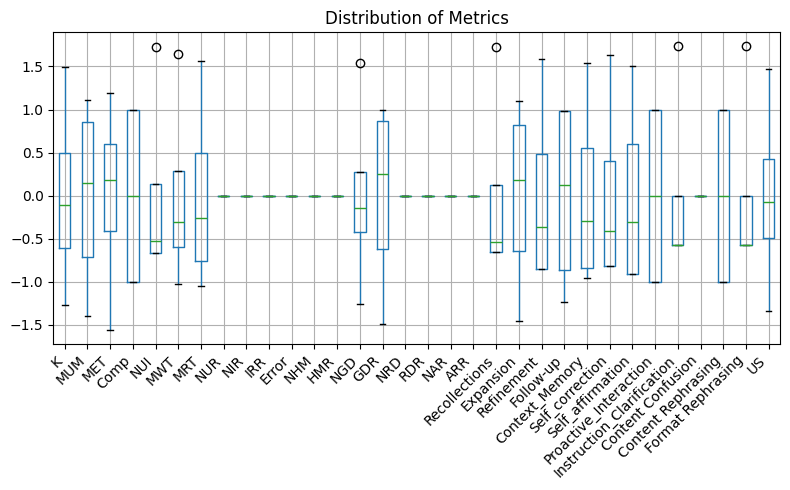

In [63]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Select the metrics you want to plot - adjust this list as needed
metrics = [c for c in df.columns if c not in ['pid']]

# Normalize/standardize if metrics are on different scales
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[metrics]), columns=metrics)

fig, ax = plt.subplots(figsize=(8, 5))
df_scaled.boxplot(column=metrics, ax=ax)
ax.set_xticklabels(metrics, rotation=45, ha='right')
ax.set_title("Distribution of Metrics")
plt.tight_layout()
plt.savefig("boxplot.png", dpi=150)
plt.show()